# Linear Regression on Predicting Road Accident Risk

## Linear regression primer

In statistics, linear regression is a linear approach for modeling the relationship between a scalar dependent variable y and one or more explanatory variables (or independent variables) denoted X. The case of one explanatory variable is called simple linear regression. For more than one explanatory variable, the process is called multiple linear regression.

Linear regression models are often fitted using the least squares approach, but they may also be fitted in other ways, such as by minimizing the "lack of fit" in some other norm (as with least absolute deviations regression), or by minimizing a penalized version of the least squares loss function as in ridge regression ($L_2$-norm penalty) and lasso ($L_1$-norm penalty). Conversely, the least squares approach can be used to fit models that are not linear models. Thus, although the terms "least squares" and "linear model" are closely linked, they are not synonymous.

### Import packages and dataset

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [173]:
df = pd.read_csv("Cleaned_Road_Accident_Risk.csv")
df.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


### Check basic info on the data set

**'info()' method to check the data types and number**

In [174]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  str    
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  str    
 5   weather                 517754 non-null  str    
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  str    
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), str(4)
memory usage: 37.5 MB


**'describe()' method to get the statistical summary of the various features of the data set**

In [175]:
df.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
10%,1.000000,0.110000,25.000000,0.000000,0.140000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
90%,4.000000,0.860000,70.000000,2.000000,0.580000
max,4.000000,1.000000,70.000000,7.000000,1.000000


**'columns' method to get the names of the columns (features)**

In [176]:
df.columns

Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='str')

### Basic plotting and visualization on the data set

**Pairplots using seaborn (lấy mẫu dữ liệu để biểu đồ dễ nhìn và chạy nhanh hơn với tập dữ liệu lớn)**

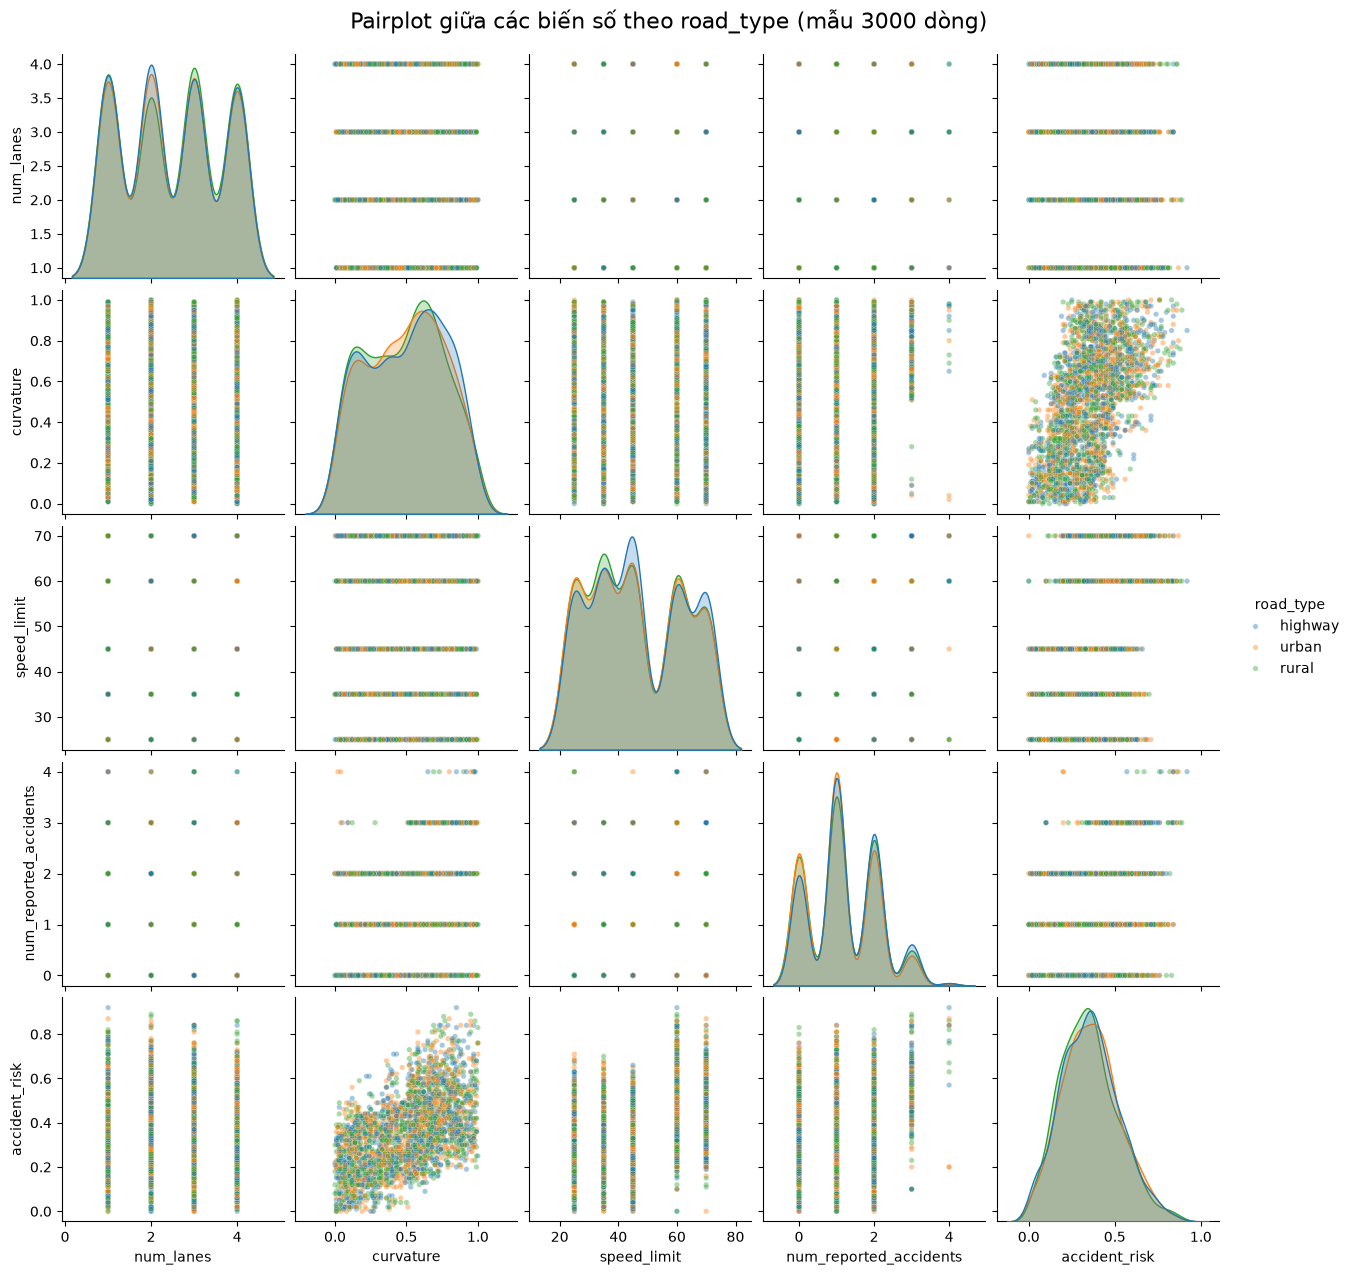

In [177]:
# Dataset có hơn 500,000 dòng nên ta lấy mẫu (sample) và chỉ dùng các cột số để pairplot
# dễ nhìn, dễ hiểu và chạy nhanh hơn. Thêm hue='road_type' để xem mối quan hệ theo từng loại đường.
plot_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk', 'road_type']
sample_df = df[plot_cols].sample(3000, random_state=42)

sns.pairplot(sample_df, hue='road_type', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle("Pairplot giữa các biến số theo road_type (mẫu 3000 dòng)", y=1.02, fontsize=16)
plt.show()

**Distribution of accident_risk (biến mục tiêu cần dự đoán)**

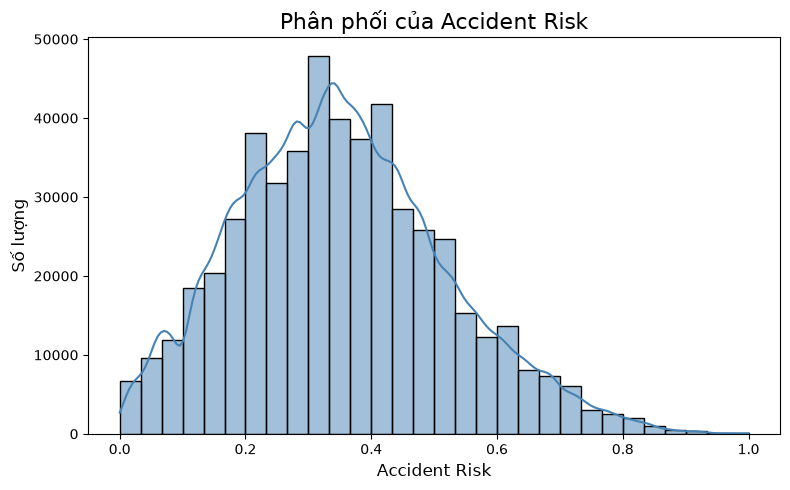

In [178]:
plt.figure(figsize=(8,5))
sns.histplot(df['accident_risk'], bins=30, kde=True, color='steelblue')
plt.title("Phân phối của Accident Risk", fontsize=16)
plt.xlabel("Accident Risk", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.tight_layout()
plt.show()

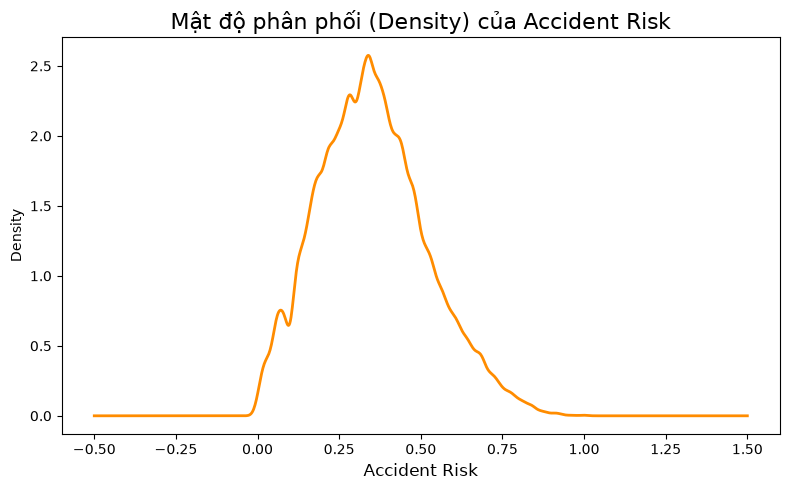

In [179]:
plt.figure(figsize=(8,5))
df['accident_risk'].plot.density(color='darkorange', linewidth=2)
plt.title("Mật độ phân phối (Density) của Accident Risk", fontsize=16)
plt.xlabel("Accident Risk", fontsize=12)
plt.tight_layout()
plt.show()

### Data Processing - Chuẩn hóa dữ liệu Boolean và Categorical

**Chuyển đổi các cột kiểu Boolean (True/False) sang số (1/0)**

In [180]:
df_model = df.copy()
bool_cols = df_model.select_dtypes(include='bool').columns.tolist()
print("Các cột Boolean:", bool_cols)

df_model[bool_cols] = df_model[bool_cols].astype(int)
df_model.head()

Các cột Boolean: ['road_signs_present', 'public_road', 'holiday', 'school_season']


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,0,1,afternoon,0,1,1,0.13
1,urban,4,0.99,35,daylight,clear,1,0,evening,1,1,0,0.35
2,rural,4,0.63,70,dim,clear,0,1,morning,1,0,2,0.30
3,highway,4,0.07,35,dim,rainy,1,1,morning,0,0,1,0.21
4,rural,1,0.58,60,daylight,foggy,0,0,evening,1,0,1,0.56


**Mã hóa các cột phân loại (Text) sang dạng số bằng One-Hot Encoding**

In [181]:
cat_cols = df_model.select_dtypes(include=['object', 'string']).columns.tolist()
print("Các cột phân loại (categorical):", cat_cols)

# drop_first=True để tránh đa cộng tuyến (dummy variable trap)
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# pd.get_dummies trả về cột kiểu bool -> chuyển tiếp sang số (1/0)
new_bool_cols = df_model.select_dtypes(include='bool').columns.tolist()
df_model[new_bool_cols] = df_model[new_bool_cols].astype(int)

df_model.head()

Các cột phân loại (categorical): ['road_type', 'lighting', 'weather', 'time_of_day']


,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,2,0.06,35,0,1,0,1,1,0.13,0,1,0,0,0,1,0,0
1,4,0.99,35,1,0,1,1,0,0.35,0,1,0,0,0,0,1,0
2,4,0.63,70,0,1,1,0,2,0.30,1,0,1,0,0,0,0,1
3,4,0.07,35,1,1,0,0,1,0.21,0,0,1,0,0,1,0,1
4,1,0.58,60,0,0,1,0,1,0.56,1,0,0,0,1,0,1,0


**Ma trận tương quan đầy đủ (sau khi đã xử lý boolean và categorical)**

In [182]:
# Tính ma trận tương quan trên df_model (SAU khi đã xử lý hết boolean và categorical)
corr_matrix = df_model.corr(numeric_only=True)
corr_matrix

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
num_lanes,1.000000,-0.020245,0.001194,-0.000498,-0.002041,0.002544,-0.001081,0.017662,-0.006003,0.000331,0.000455,0.001352,-0.001150,0.002897,-0.006619,-0.001021,-0.000964
curvature,-0.020245,1.000000,0.008399,0.017168,0.048220,0.063931,-0.004502,0.145034,0.543946,-0.001515,0.010403,-0.008077,0.000850,0.045515,-0.063868,0.002818,-0.001502
speed_limit,0.001194,0.008399,1.000000,-0.004461,0.011497,0.010992,0.004392,0.031373,0.430898,0.001285,0.008298,0.030502,-0.076318,-0.001255,-0.078670,0.000252,-0.003501
road_signs_present,-0.000498,0.017168,-0.004461,1.000000,0.003828,-0.003813,0.002287,-0.000162,0.000629,0.000253,0.000705,0.000317,-0.006782,-0.003685,0.006567,-0.004906,0.009339
public_road,-0.002041,0.048220,0.011497,0.003828,1.000000,-0.007920,0.004117,-0.007026,0.031032,-0.001484,-0.000058,-0.000813,0.000057,-0.000056,0.010340,-0.001142,0.002568
holiday,0.002544,0.063931,0.010992,-0.003813,-0.007920,1.000000,-0.001514,-0.015053,0.051129,-0.002176,-0.000336,-0.006845,0.016977,-0.002123,0.022232,-0.003769,0.005864
school_season,-0.001081,-0.004502,0.004392,0.002287,0.004117,-0.001514,1.000000,0.003962,-0.000977,-0.002164,0.001104,0.003317,-0.003191,-0.004432,0.003099,-0.006061,0.012466
num_reported_accidents,0.017662,0.145034,0.031373,-0.000162,-0.007026,-0.015053,0.003962,1.000000,0.213891,-0.004631,0.003660,-0.031970,0.051662,0.001028,0.037935,0.001238,-0.003078
accident_risk,-0.006003,0.543946,0.430898,0.000629,0.031032,0.051129,-0.000977,0.213891,1.000000,-0.010121,0.021463,-0.233032,0.465798,0.149758,0.036137,0.010032,-0.006019
road_type_rural,0.000331,-0.001515,0.001285,0.000253,-0.001484,-0.002176,-0.002164,-0.004631,-0.010121,1.000000,-0.497638,0.006600,-0.013023,-0.001509,-0.002719,-0.002599,0.000388


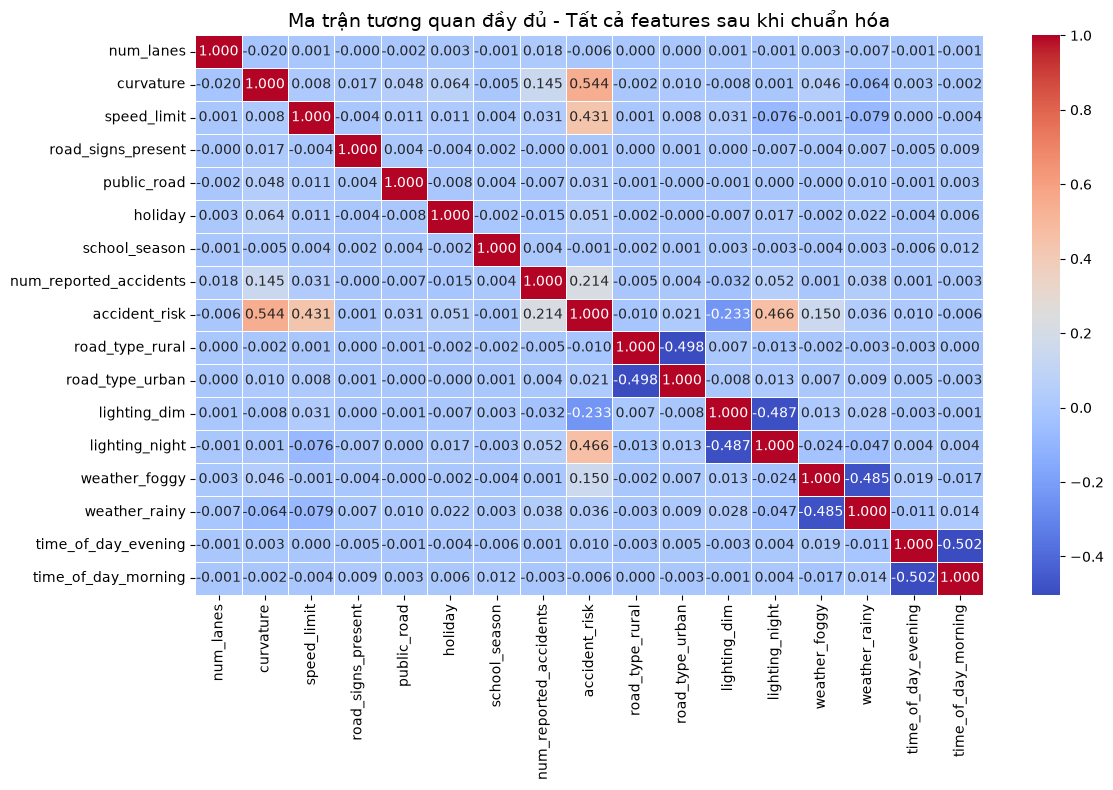

In [183]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", linewidths=0.5)
plt.title("Ma trận tương quan đầy đủ - Tất cả features sau khi chuẩn hóa", fontsize=14)
plt.tight_layout()
plt.show()

**Loại bỏ các cột có tương quan rất thấp với accident_risk**

In [184]:
# Lấy tương quan của từng biến với accident_risk, sắp xếp theo trị tuyệt đối giảm dần
corr_with_target = corr_matrix['accident_risk'].drop('accident_risk').sort_values(key=abs, ascending=False)
print("Tương quan của TẤT CẢ features với accident_risk (sau chuẩn hóa):\n")
print(corr_with_target)

# Ngưỡng tương quan tối thiểu để giữ lại cột
threshold = 0.02
weak_cols = corr_with_target[corr_with_target.abs() < threshold].index.tolist()
print("\nCác cột có tương quan yếu (< {}), sẽ bị loại bỏ:".format(threshold))
print(weak_cols)

Tương quan của TẤT CẢ features với accident_risk (sau chuẩn hóa):

curvature                 0.543946
lighting_night            0.465798
speed_limit               0.430898
lighting_dim             -0.233032
num_reported_accidents    0.213891
weather_foggy             0.149758
holiday                   0.051129
weather_rainy             0.036137
public_road               0.031032
road_type_urban           0.021463
road_type_rural          -0.010121
time_of_day_evening       0.010032
time_of_day_morning      -0.006019
num_lanes                -0.006003
school_season            -0.000977
road_signs_present        0.000629
Name: accident_risk, dtype: float64

Các cột có tương quan yếu (< 0.02), sẽ bị loại bỏ:
['road_type_rural', 'time_of_day_evening', 'time_of_day_morning', 'num_lanes', 'school_season', 'road_signs_present']


In [185]:
# Loại bỏ weak_cols từ df_model
df_model = df_model.drop(columns=weak_cols)
print(f"Còn lại {len(df_model.columns)} cột sau khi loại bỏ các cột yếu")
df_model.head()

Còn lại 11 cột sau khi loại bỏ các cột yếu


,curvature,speed_limit,public_road,holiday,num_reported_accidents,accident_risk,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy
0,0.06,35,1,0,1,0.13,1,0,0,0,1
1,0.99,35,0,1,0,0.35,1,0,0,0,0
2,0.63,70,1,1,2,0.30,0,1,0,0,0
3,0.07,35,1,0,1,0.21,0,1,0,0,1
4,0.58,60,0,1,1,0.56,0,0,0,1,0


**Make a list of data frame column names**

In [186]:
l_column = list(df_model.columns) # Making a list out of column names
len_feature = len(l_column) # Length of column vector list
l_column

['curvature',
 'speed_limit',
 'public_road',
 'holiday',
 'num_reported_accidents',
 'accident_risk',
 'road_type_urban',
 'lighting_dim',
 'lighting_night',
 'weather_foggy',
 'weather_rainy']

**Put all the remaining features in X and accident_risk (biến mục tiêu) trong y**

In [187]:
y = df_model['accident_risk']
X = df_model.drop(columns=['accident_risk'])

In [188]:
print("Feature set size:",X.shape)
print("Variable set size:",y.shape)

Feature set size: (517754, 10)
Variable set size: (517754,)


In [189]:
X.head()

,curvature,speed_limit,public_road,holiday,num_reported_accidents,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy
0,0.06,35,1,0,1,1,0,0,0,1
1,0.99,35,0,1,0,1,0,0,0,0
2,0.63,70,1,1,2,0,1,0,0,0
3,0.07,35,1,0,1,0,1,0,0,1
4,0.58,60,0,1,1,0,0,0,1,0


In [190]:
y.head()

0    0.13
1    0.35
2    0.30
3    0.21
4    0.56
Name: accident_risk, dtype: float64

### Test-train split

**Import train_test_split function from scikit-learn**

In [191]:
from sklearn.model_selection import train_test_split

**Create X and y train and test splits in one command: chia dữ liệu thành 99% train / 1% test, kèm random seed**

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=123)

**Check the size and shape of train/test splits (it should be in the ratio as per test_size parameter above)**

In [193]:
print("Training feature set size:",X_train.shape)
print("Test feature set size:",X_test.shape)
print("Training variable set size:",y_train.shape)
print("Test variable set size:",y_test.shape)

Training feature set size: (512576, 10)
Test feature set size: (5178, 10)
Training variable set size: (512576,)
Test variable set size: (5178,)


### Model fit and training

**Import linear regression model estimator from scikit-learn and instantiate**

In [194]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [195]:
lm = LinearRegression() # Creating a Linear Regression object 'lm'

**Fit the model on to the instantiated object itself**

In [196]:
lm.fit(X_train,y_train) # Fit the linear model on to the 'lm' object itself i.e. no need to set this to another variable

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.32, 0.01,-0. ,..., 0.19, 0.09, 0.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['curvature','speed_limit','public_road',...,'lighting_night', 'weather_foggy','weather_rainy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.1764
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


**Check the intercept and coefficients and put them in a DataFrame**

In [197]:
print("The intercept term of the linear model:", lm.intercept_)

The intercept term of the linear model: -0.1764492115986706


In [198]:
print("The coefficients of the linear model:", lm.coef_)

The coefficients of the linear model: [ 3.24629579e-01  5.09903378e-03 -7.53388255e-04 -2.96039868e-04
  1.57632132e-02  2.71212396e-04  3.99959278e-06  1.87324100e-01
  9.17378965e-02  9.29701550e-02]


In [199]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
curvature,0.324630
speed_limit,0.005099
public_road,-0.000753
holiday,-0.000296
num_reported_accidents,0.015763
road_type_urban,0.000271
lighting_dim,0.000004
lighting_night,0.187324
weather_foggy,0.091738
weather_rainy,0.092970


### Calculation of standard errors and t-statistic for the coefficients

In [200]:
n=X_train.shape[0]
k=X_train.shape[1]
dfN = n-k
train_pred=lm.predict(X_train)
train_error = np.square(train_pred - y_train)
sum_error=np.sum(train_error)
se=[0]*k   # số lượng feature giờ là biến động (do One-Hot Encoding) nên dùng [0]*k thay vì hardcode 5 phần tử
for i in range(k):
    r = (sum_error/dfN)
    r = r/np.sum(np.square(X_train[list(X_train.columns)[i]]-X_train[list(X_train.columns)[i]].mean()))
    se[i]=np.sqrt(r)
cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coefficients']/cdf['Standard Error']
cdf

,Coefficients,Standard Error,t-statistic
curvature,0.324630,0.000377,861.696850
speed_limit,0.005099,0.000007,784.039534
public_road,-0.000753,0.000205,-3.668491
holiday,-0.000296,0.000205,-1.441496
num_reported_accidents,0.015763,0.000115,137.561593
road_type_urban,0.000271,0.000218,1.242790
lighting_dim,0.000004,0.000215,0.018638
lighting_night,0.187324,0.000224,836.932041
weather_foggy,0.091738,0.000215,426.220296
weather_rainy,0.092970,0.000223,416.228079


In [201]:
print("Therefore, features arranged in the order of importance for predicting the accident risk\n",'-'*90,sep='')
l=list(cdf.sort_values('t-statistic',ascending=False).index)
print(' > \n'.join(l))

Therefore, features arranged in the order of importance for predicting the accident risk
------------------------------------------------------------------------------------------
curvature > 
lighting_night > 
speed_limit > 
weather_foggy > 
weather_rainy > 
num_reported_accidents > 
road_type_urban > 
lighting_dim > 
holiday > 
public_road


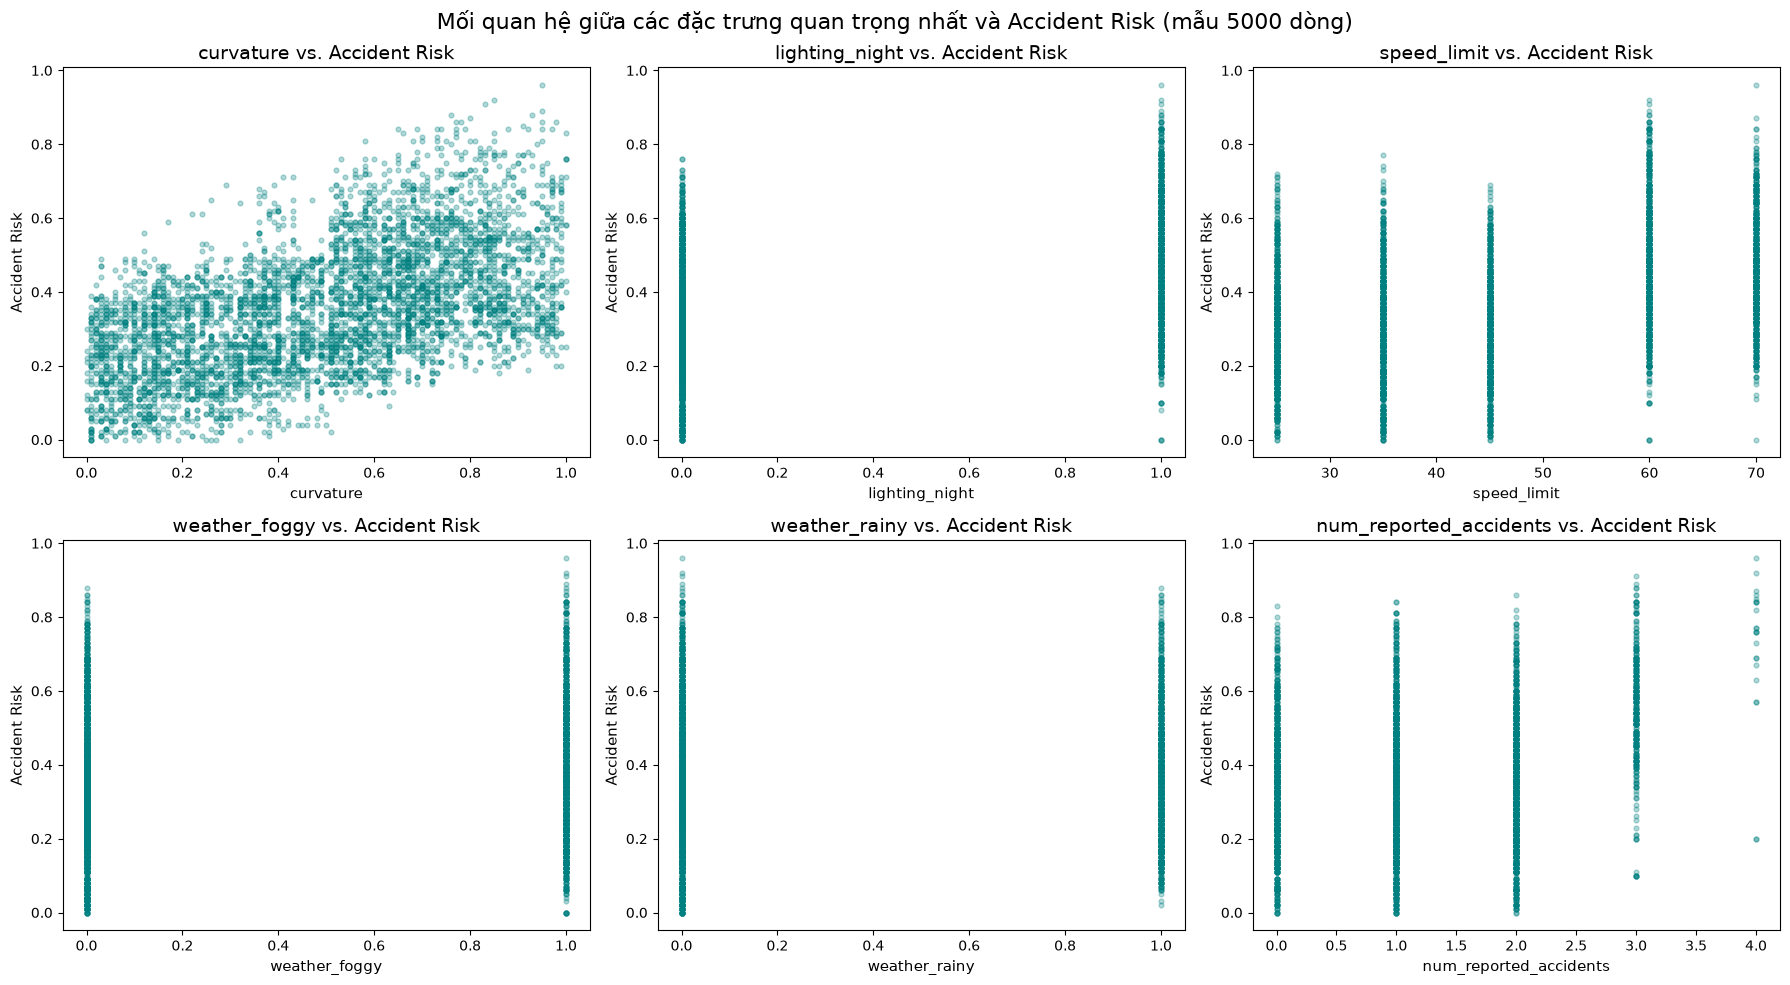

In [202]:
# Lấy 6 đặc trưng quan trọng nhất (theo |t-statistic|) để vẽ scatter plot cho dễ nhìn,
# thay vì hardcode số lượng cột cố định như bản gốc
top_n = 6
top_features = cdf['t-statistic'].abs().sort_values(ascending=False).index[:top_n]

# Lấy mẫu dữ liệu để vẽ cho nhanh và đỡ chồng chéo điểm (dataset có hơn 500,000 dòng)
sample_plot = df_model.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(top_features):
    axes[i].scatter(sample_plot[col], sample_plot['accident_risk'], alpha=0.3, s=12, color='teal')
    axes[i].set_title(f"{col} vs. Accident Risk", fontsize=14)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Accident Risk", fontsize=11)

fig.suptitle("Mối quan hệ giữa các đặc trưng quan trọng nhất và Accident Risk (mẫu 5000 dòng)", fontsize=16)
plt.tight_layout()
plt.show()

**R-square of the model fit**

In [203]:
print("R-squared value of this fit:",round(metrics.r2_score(y_train,train_pred),3))

R-squared value of this fit: 0.805


### Prediction, error estimate, and regression evaluation matrices

**Prediction using the lm model**

In [204]:
predictions = lm.predict(X_test)
print ("Type of the predicted object:", type(predictions))
print ("Size of the predicted object:", predictions.shape)

Type of the predicted object: <class 'numpy.ndarray'>
Size of the predicted object: (5178,)


**Scatter plot of predicted accident risk và y_test set để xem dữ liệu có nằm gần đường chéo 45 độ hay không (đã thêm đường tham chiếu màu đỏ cho dễ quan sát)**

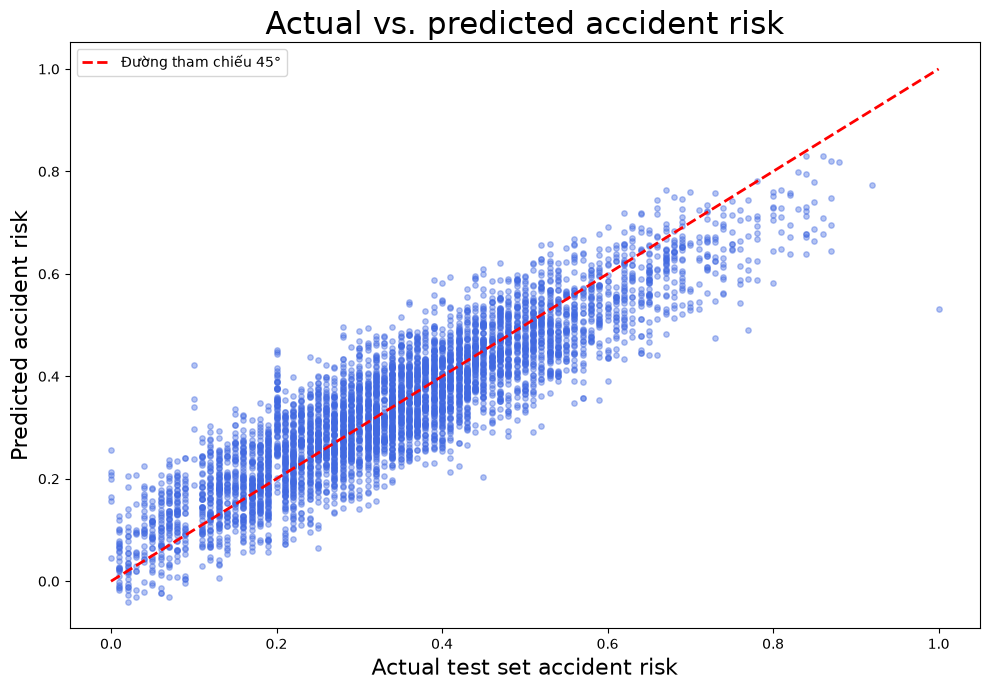

In [205]:
plt.figure(figsize=(10,7))
plt.title("Actual vs. predicted accident risk",fontsize=22)
plt.xlabel("Actual test set accident risk",fontsize=16)
plt.ylabel("Predicted accident risk", fontsize=16)
plt.scatter(x=y_test,y=predictions, alpha=0.4, s=15, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Đường tham chiếu 45°')
plt.legend()
plt.tight_layout()
plt.show()

**Plotting histogram of the residuals i.e. predicted errors (expect a normally distributed pattern)**

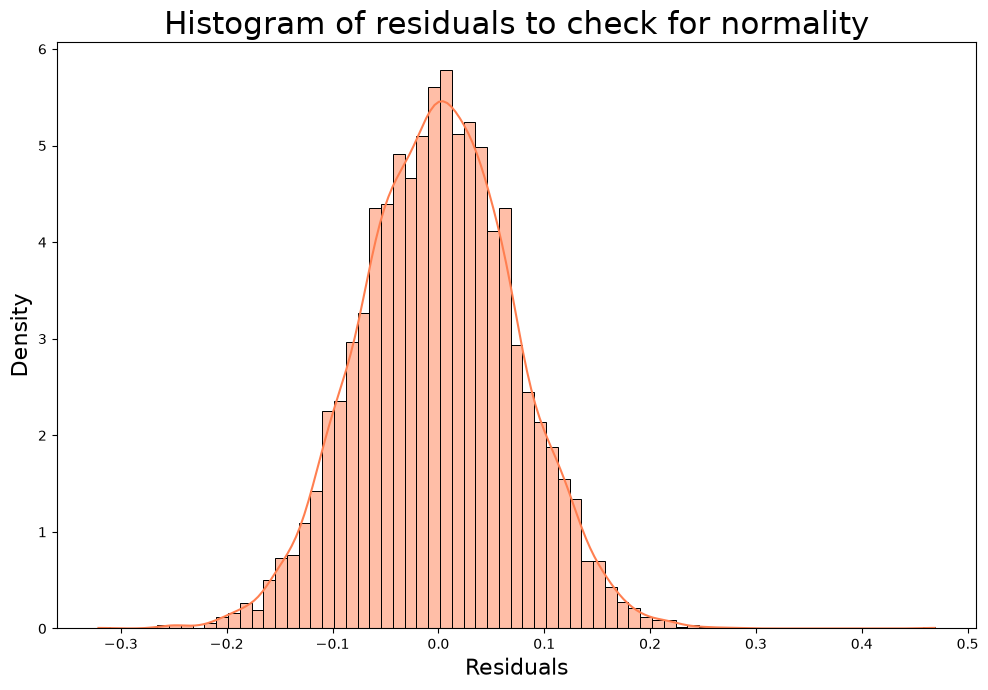

In [206]:
plt.figure(figsize=(10,7))
plt.title("Histogram of residuals to check for normality",fontsize=22)
plt.xlabel("Residuals",fontsize=16)
plt.ylabel("Density", fontsize=16)
sns.histplot((y_test-predictions), kde=True, color='coral', stat='density')
plt.tight_layout()
plt.show()

**Scatter plot of residuals and predicted values (Homoscedasticity), đã thêm đường y=0 màu đỏ để dễ quan sát**

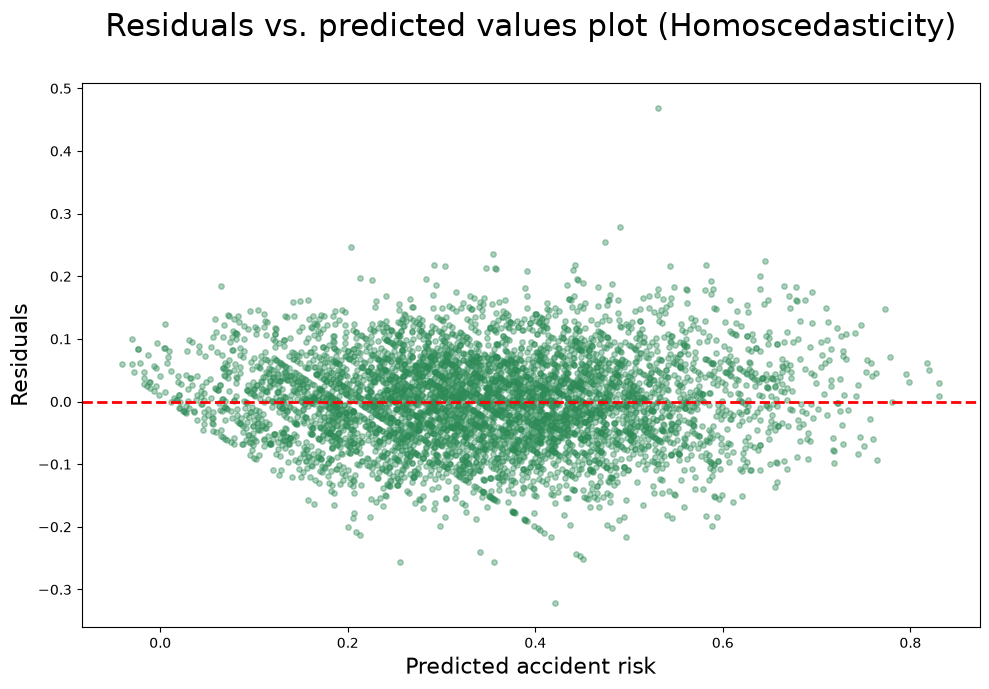

In [207]:
plt.figure(figsize=(10,7))
plt.title("Residuals vs. predicted values plot (Homoscedasticity)\n",fontsize=22)
plt.xlabel("Predicted accident risk",fontsize=16)
plt.ylabel("Residuals", fontsize=16)
plt.scatter(x=predictions,y=y_test-predictions, alpha=0.4, s=15, color='seagreen')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

**Regression evaluation metrices**

In [208]:
print("Mean absolute error (MAE):", metrics.mean_absolute_error(y_test,predictions))
print("Mean square error (MSE):", metrics.mean_squared_error(y_test,predictions))
print("Root mean square error (RMSE):", np.sqrt(metrics.mean_squared_error(y_test,predictions)))

Mean absolute error (MAE): 0.057663380287205426
Mean square error (MSE): 0.00526164082964907
Root mean square error (RMSE): 0.0725371686078873


**R-square value**

In [209]:
print("R-squared value of predictions:",round(metrics.r2_score(y_test,predictions),3))

R-squared value of predictions: 0.805
